In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, Attention, Layer, Input
from tensorflow.keras import Model

def build_lstm_model(model_type, input_shape):
    """
    Tipos: 'stacked', 'bidirectional', 'attention'
    """
    inputs = Input(shape=input_shape)

    if model_type == 'stacked':
        x = LSTM(64, return_sequences=True, activation='relu')(inputs)
        x = Dropout(0.2)(x)
        x = LSTM(32, activation='relu')(x)
        x = Dropout(0.2)(x)

    elif model_type == 'bidirectional':
        x = Bidirectional(LSTM(64, return_sequences=True, activation='relu'))(inputs)
        x = Dropout(0.2)(x)
        x = Bidirectional(LSTM(32, activation='relu'))(x)
        x = Dropout(0.2)(x)

    elif model_type == 'attention':
        # Capa LSTM que devuelve secuencias para que la Atención pueda "mirar" atrás
        lstm_out = LSTM(64, return_sequences=True, activation='relu')(inputs)
        # Mecanismo de Atención simplificado (Self-Attention)
        query = Dense(64)(lstm_out)
        value = Dense(64)(lstm_out)
        attention_layer = Attention()([query, value])
        # Reducimos a un vector global (Global Average Pooling o similar)
        x = tf.keras.layers.GlobalAveragePooling1D()(attention_layer)
        x = Dense(32, activation='relu')(x)

    outputs = Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Pinar del Rio

In [25]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Pinar_del_Río'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med",'Humedad Relat', 'Temperatura med_lag17', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag17'],
      dtype='object')
(426, 8, 7) (4, 8, 7)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.0863

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 46.82 casos
RMSE Real: 55.46
MAPE Real: 37.67%


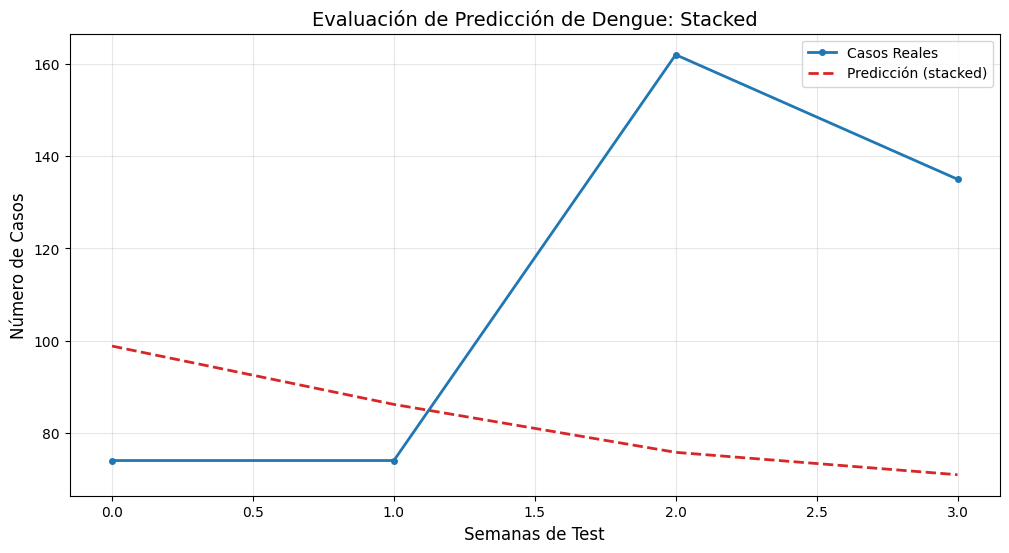


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.0974

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 43.25 casos
RMSE Real: 59.70
MAPE Real: 30.02%


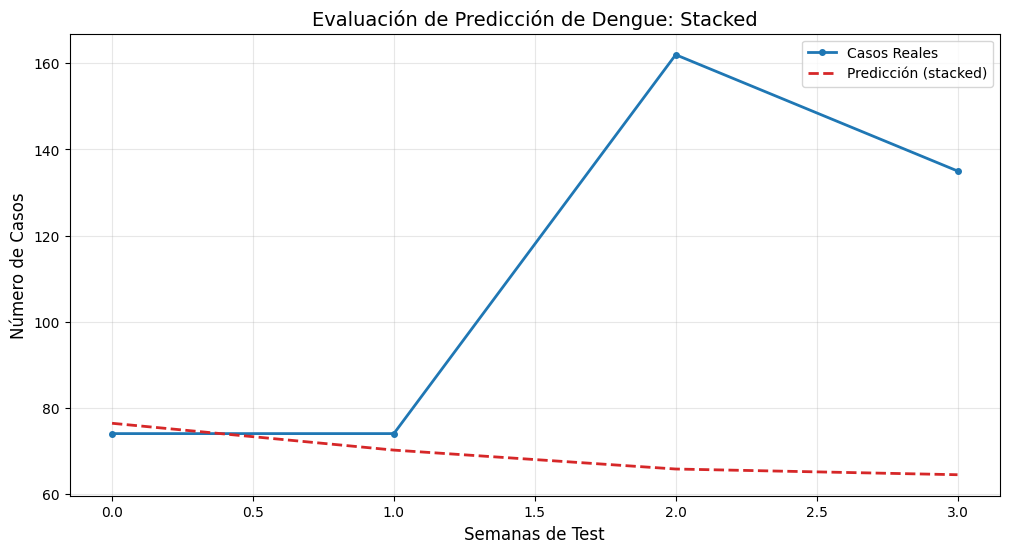


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.0955

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 47.25 casos
RMSE Real: 60.58
MAPE Real: 35.20%


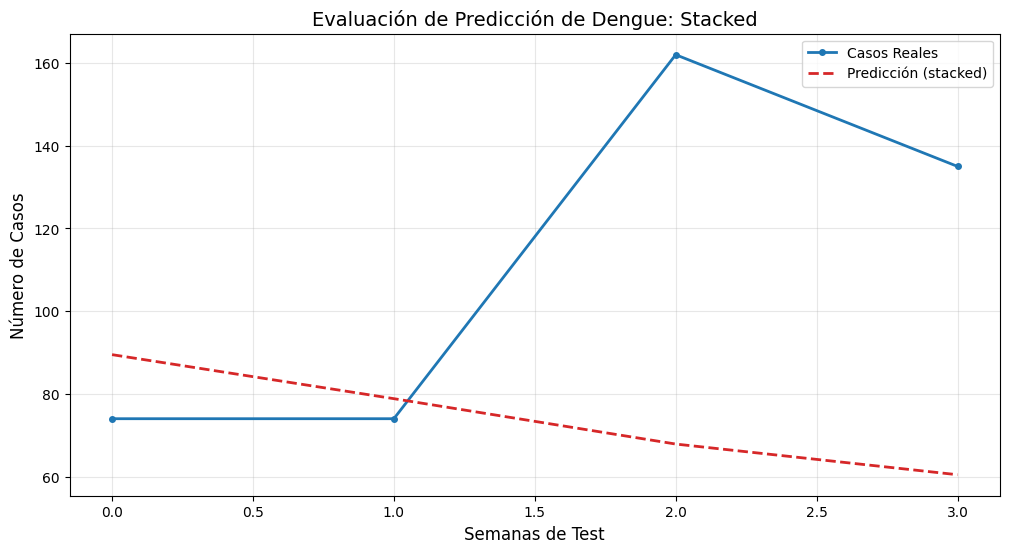

In [26]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Artemisa

In [23]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Artemisa'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med",'Humedad Relat', 'Precipitaciones_lag5', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5'],
      dtype='object')
(435, 8, 7) (4, 8, 7)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.0967

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 41.55 casos
RMSE Real: 51.94
MAPE Real: 33.26%


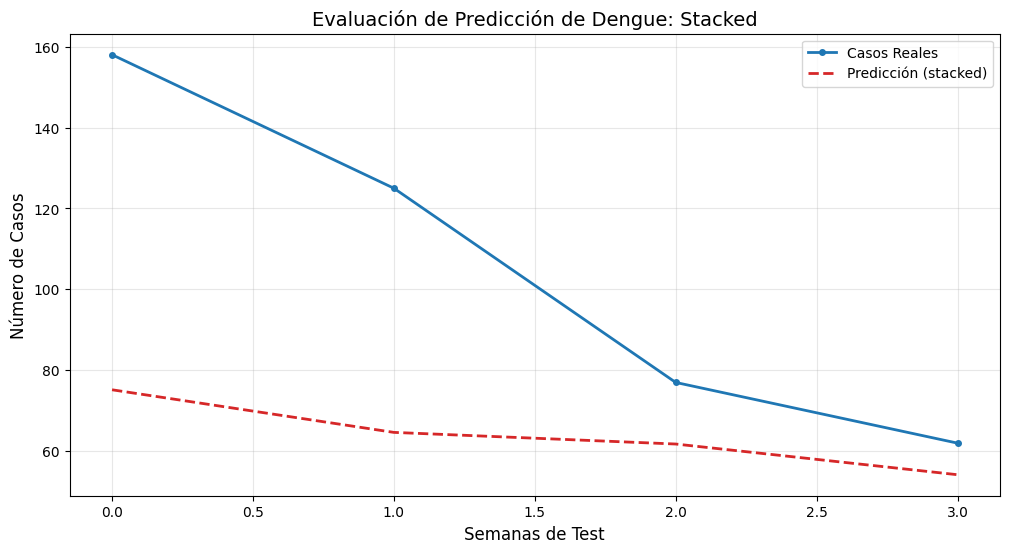


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1534

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 25.82 casos
RMSE Real: 29.36
MAPE Real: 23.37%


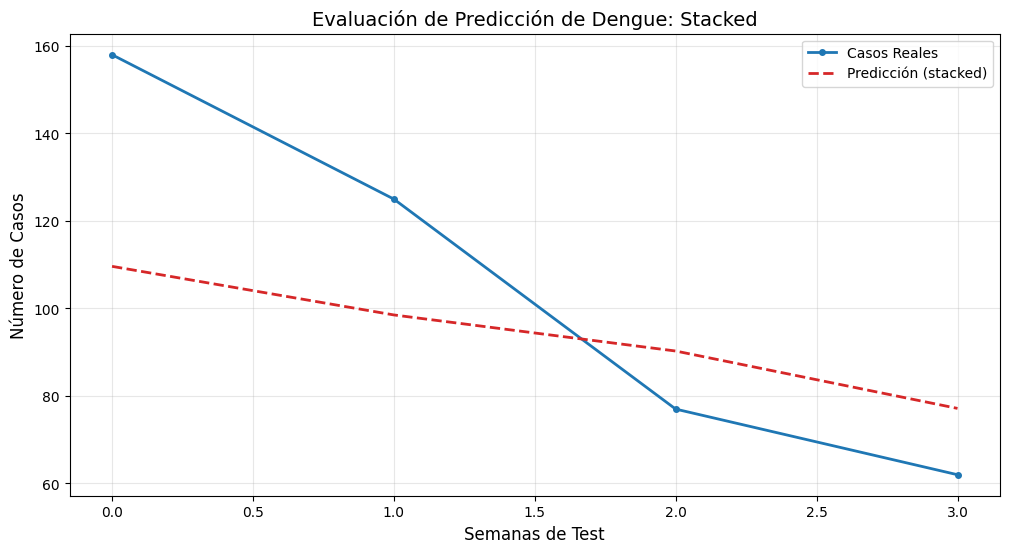


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.1085

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 28.79 casos
RMSE Real: 38.92
MAPE Real: 21.40%


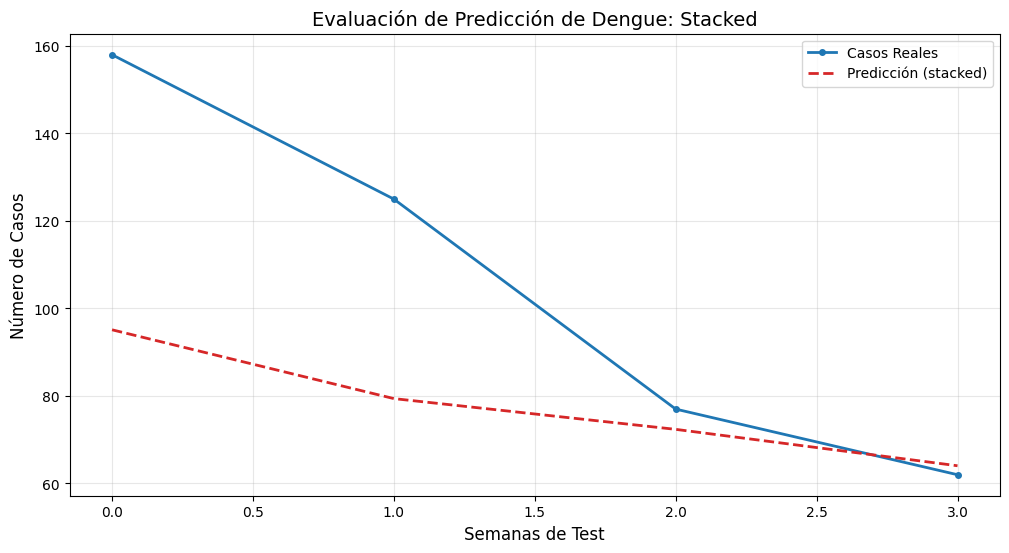

In [24]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# La Habana

In [21]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'La_Habana'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med", 'Humedad Relat', 'Temperatura med_lag6', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag6'],
      dtype='object')
(435, 8, 7) (4, 8, 7)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.1449

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 377.05 casos
RMSE Real: 382.02
MAPE Real: 46.84%


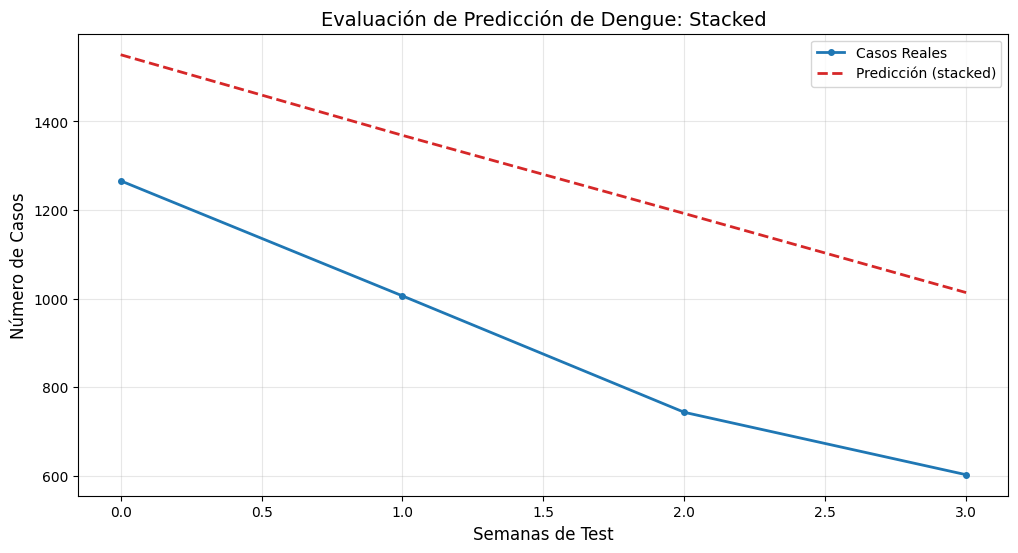


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1088

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 226.81 casos
RMSE Real: 229.05
MAPE Real: 27.35%


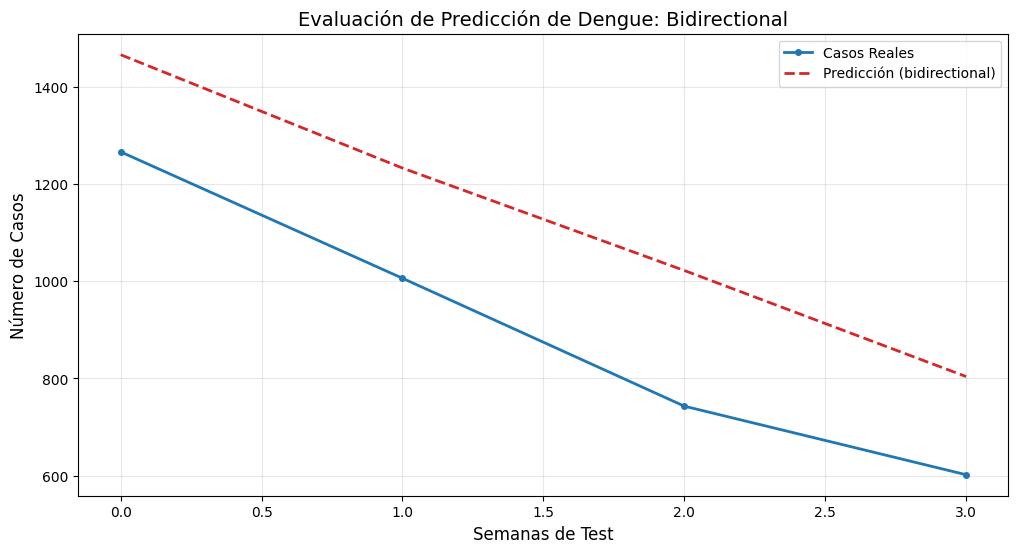


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.1613

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 444.90 casos
RMSE Real: 446.37
MAPE Real: 52.74%


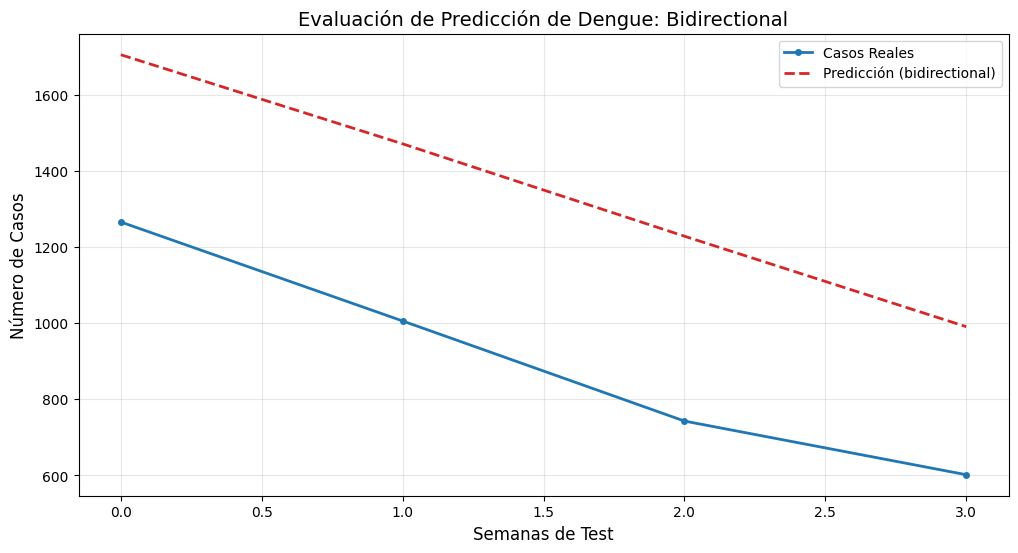

In [22]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Mayabeque

In [28]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Mayabeque'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med",'Precipitaciones_lag5', 'Precipitaciones_lag13', 'Humedad Relat', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5', 'Precipitaciones_lag13'],
      dtype='object')
(430, 8, 8) (4, 8, 8)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.1126

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 97.86 casos
RMSE Real: 115.35
MAPE Real: 81.31%


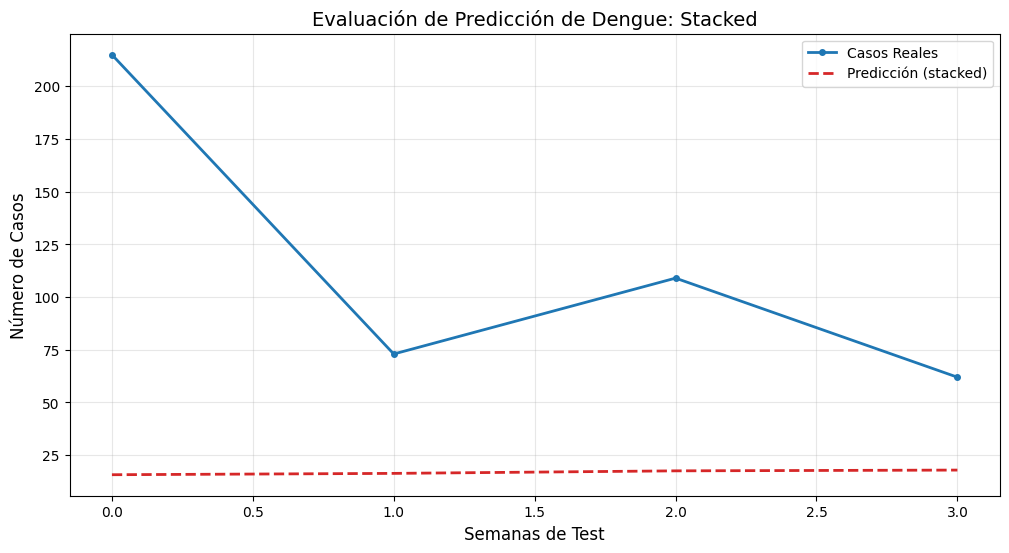


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1137

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 39.81 casos
RMSE Real: 47.39
MAPE Real: 37.42%


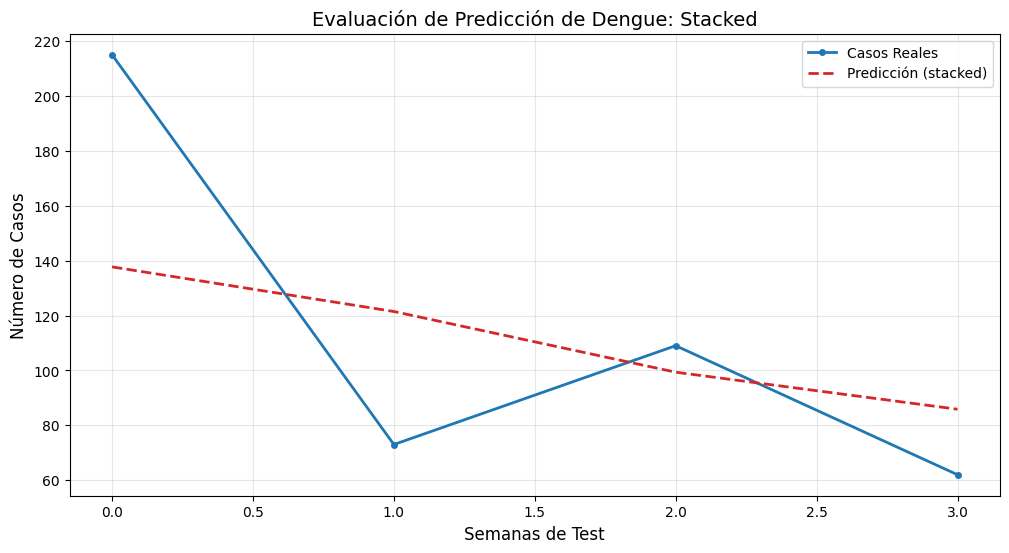


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.3362

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 206.07 casos
RMSE Real: 216.04
MAPE Real: 197.99%


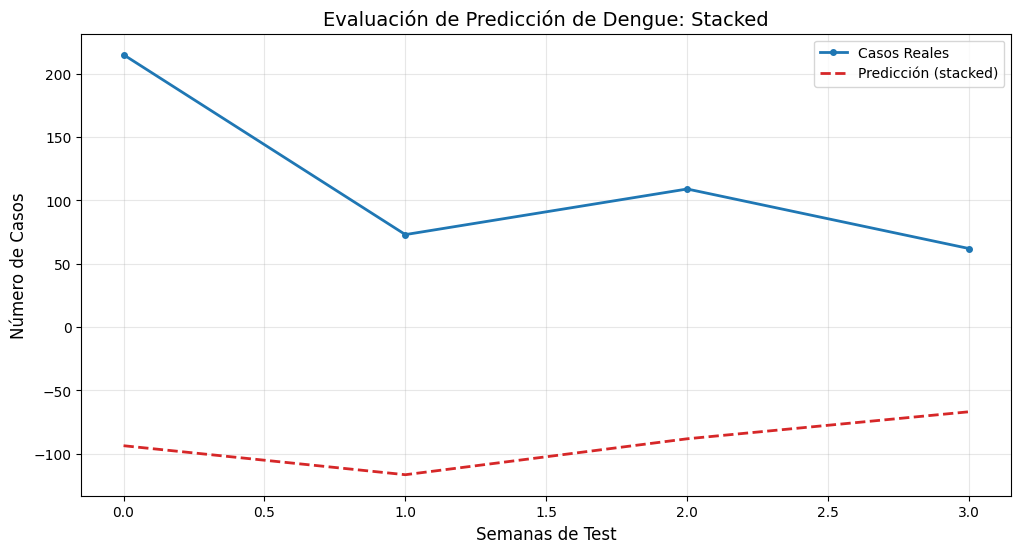

In [29]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Matanzas

In [74]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Matanzas'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = ['Temp_Med','Hum_Rel', 'Precip']


data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')
(440, 8, 3) (4, 8, 3)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.0612

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 1.14 casos
RMSE Real: 1.17
MAPE Real: 4.42%


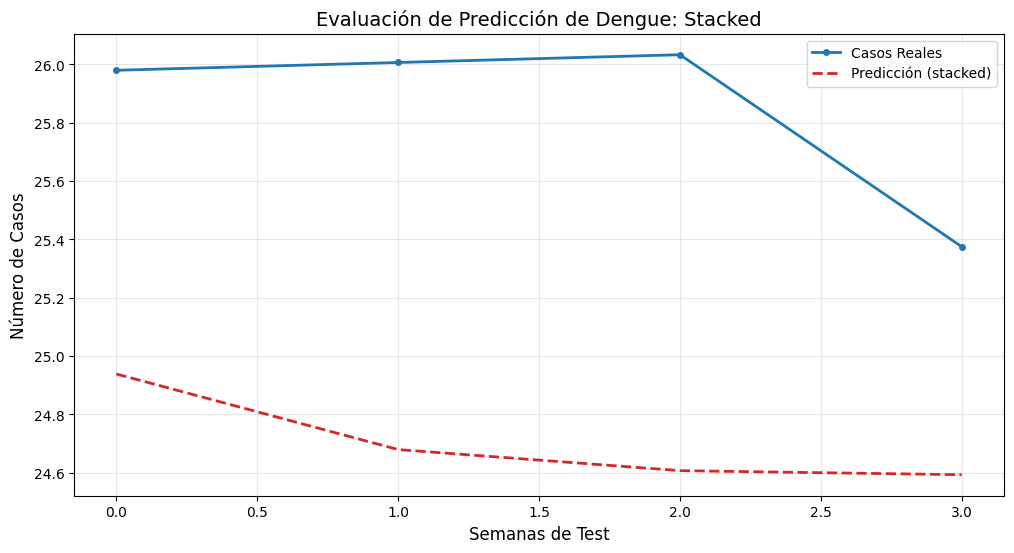


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.0531

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 0.67 casos
RMSE Real: 0.71
MAPE Real: 2.57%


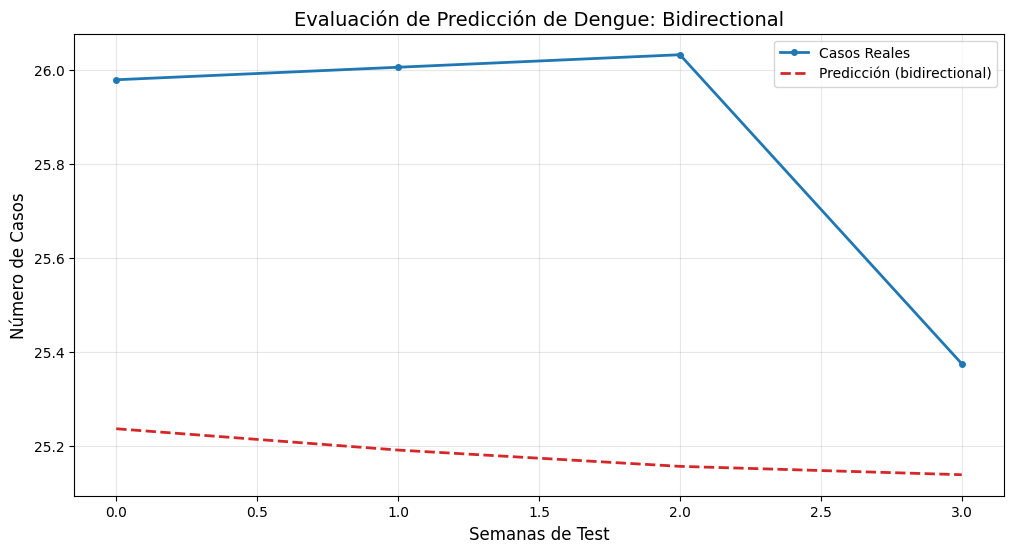


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.1268

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 2.27 casos
RMSE Real: 2.28
MAPE Real: 8.77%


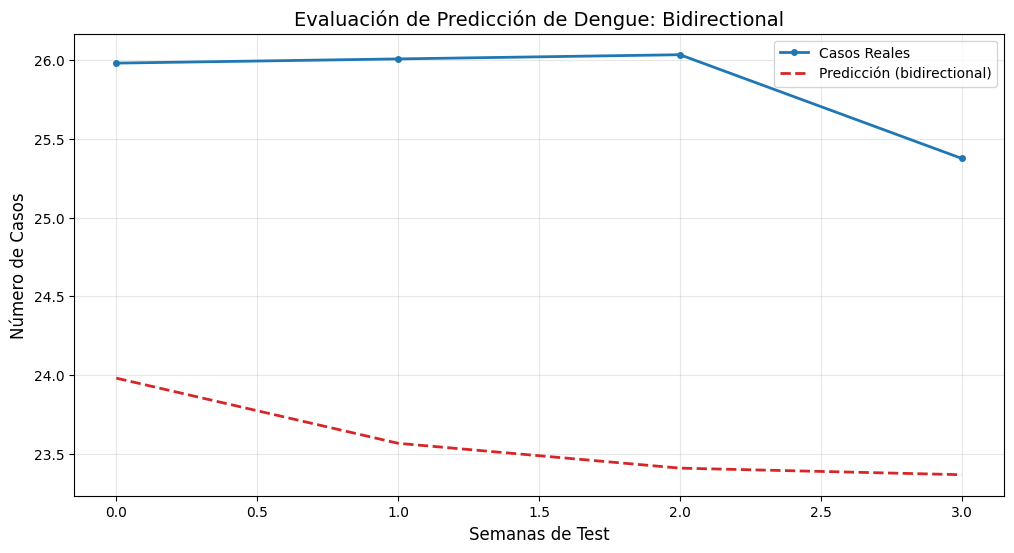

In [75]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Cienfuegos

In [72]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Cienfuegos'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = ['Temp_Med','Hum_Rel', 'Precip']


data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')
(440, 8, 3) (4, 8, 3)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.0356

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 0.36 casos
RMSE Real: 0.47
MAPE Real: 1.43%


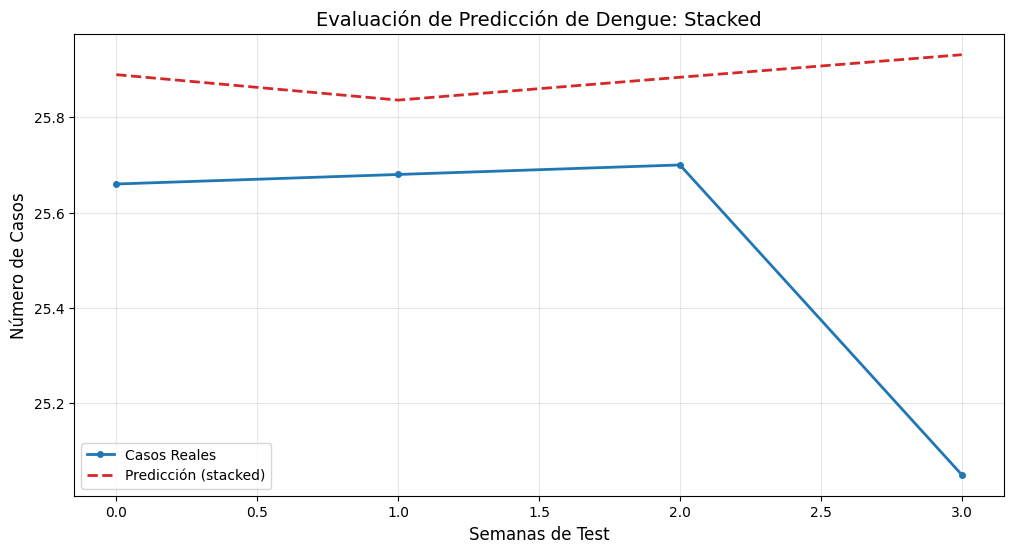


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.0247

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 0.20 casos
RMSE Real: 0.23
MAPE Real: 0.77%


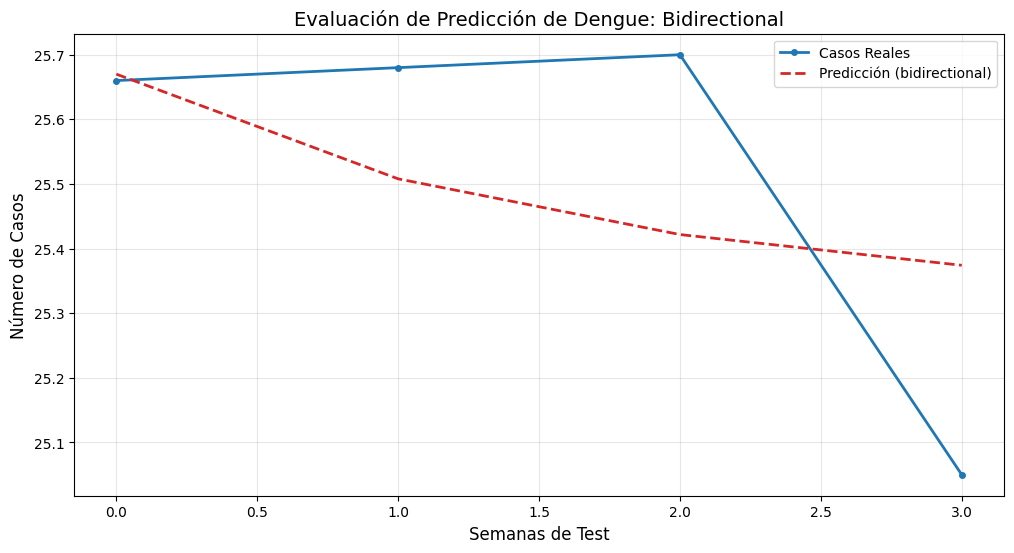


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.0283

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 0.22 casos
RMSE Real: 0.27
MAPE Real: 0.87%


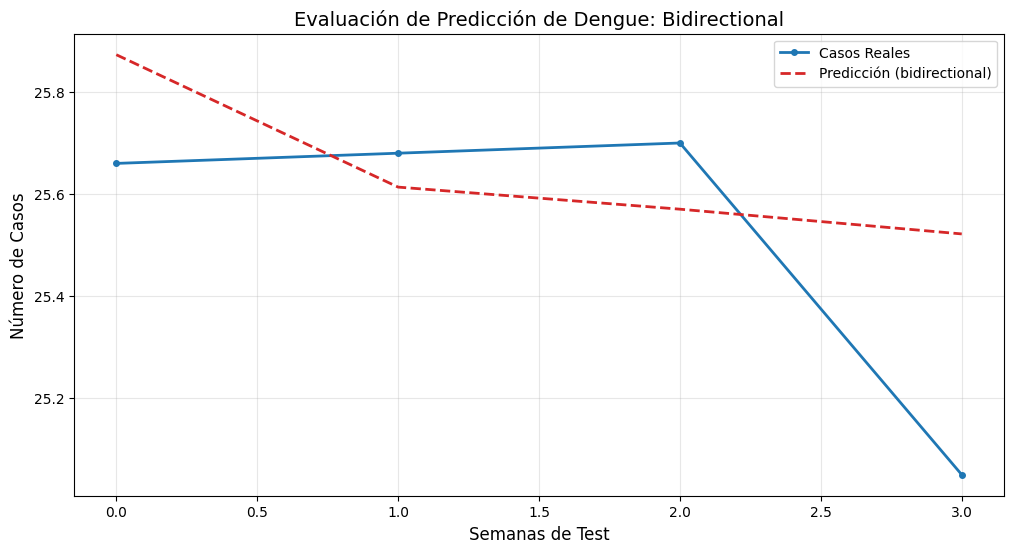

In [73]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Sancti Spriritus

In [69]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Sancti_Spíritus'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = ['Temp_Med','Hum_Rel', 'Precip']

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')
(440, 8, 3) (4, 8, 3)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.1096

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 0.15 casos
RMSE Real: 0.21
MAPE Real: 0.61%


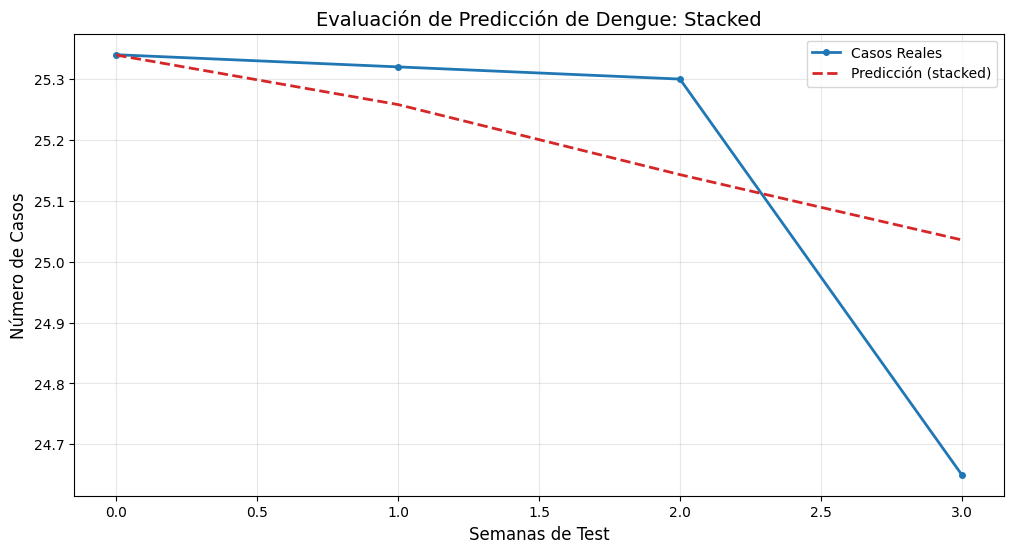


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1384

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 1.36 casos
RMSE Real: 1.38
MAPE Real: 5.39%


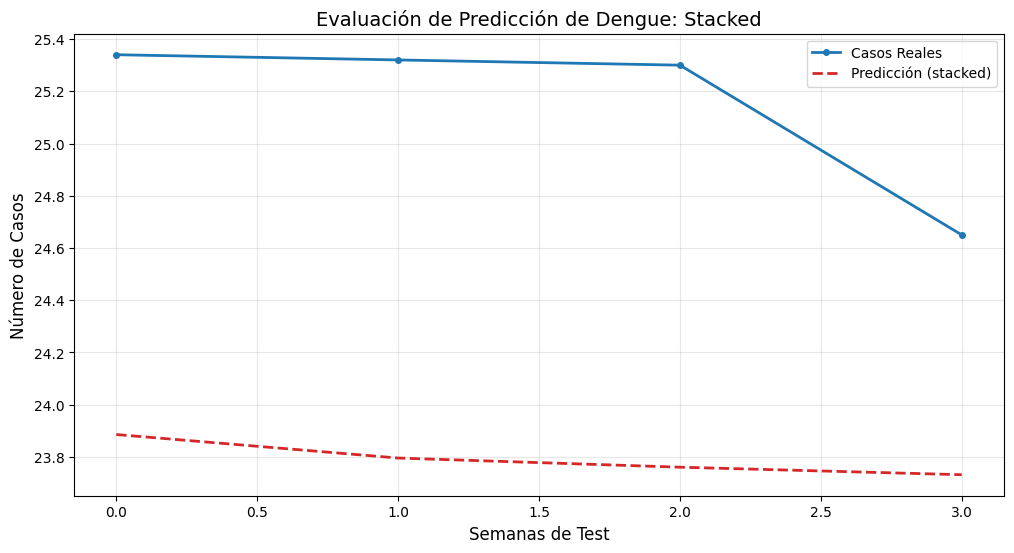


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.1028

🏆 Mejor Modelo Detectado: ATTENTION
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 0.21 casos
RMSE Real: 0.22
MAPE Real: 0.82%


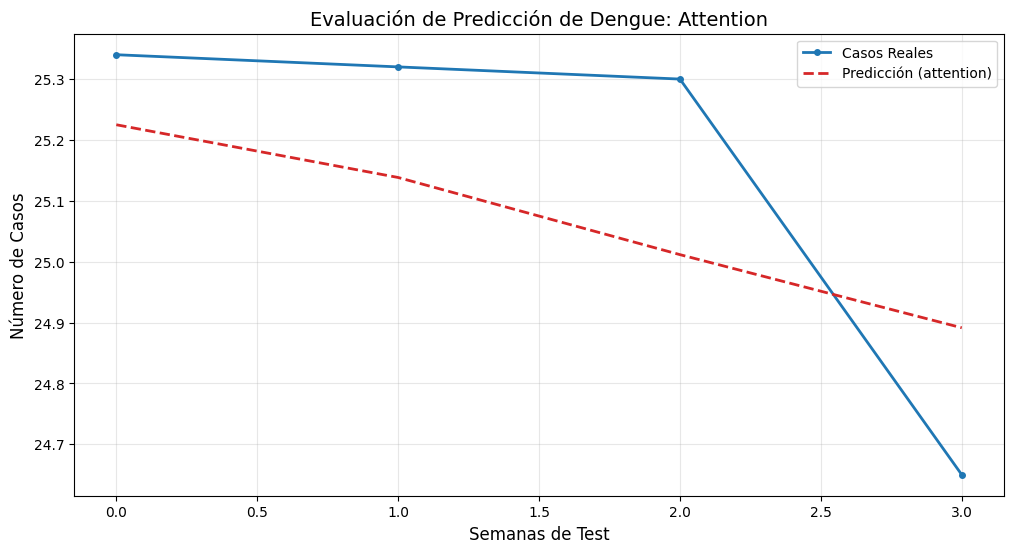

In [70]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Villa Clara

In [37]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Villa_Clara'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med", 'Humedad Relat',
    'Temperatura med_lag6', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Temperatura med_lag6'],
      dtype='object')
(435, 8, 7) (4, 8, 7)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.1784

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 202.28 casos
RMSE Real: 203.28
MAPE Real: 56.93%


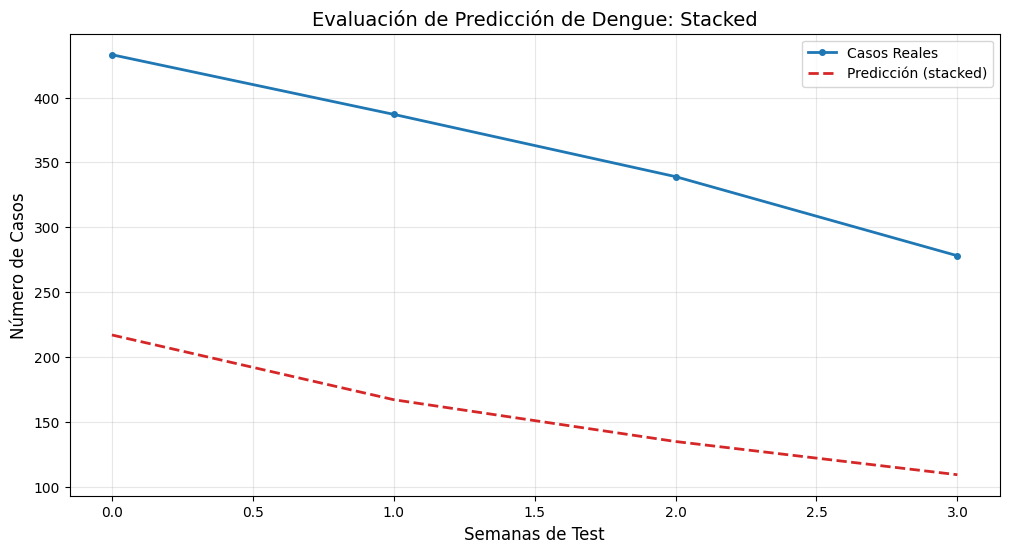


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.0515

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 45.51 casos
RMSE Real: 52.66
MAPE Real: 11.75%


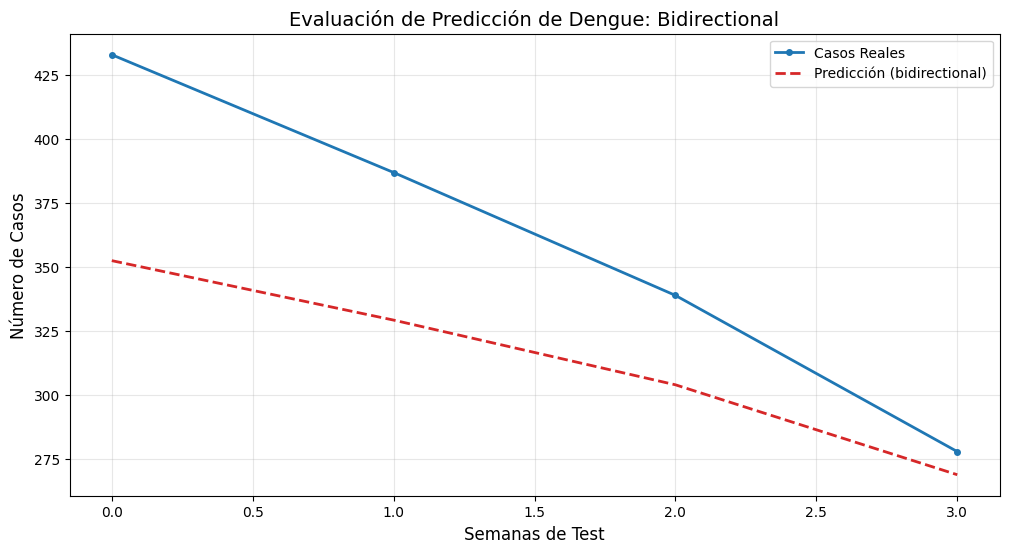


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.0486

🏆 Mejor Modelo Detectado: ATTENTION
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 60.31 casos
RMSE Real: 66.03
MAPE Real: 15.95%


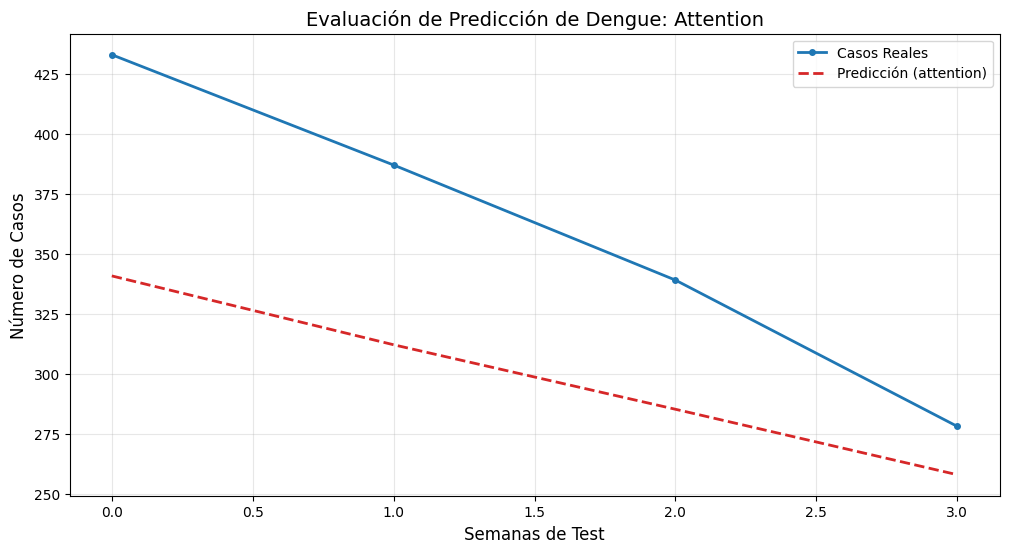

In [38]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



# Ciego de Avila




In [65]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Ciego_de_Ávila'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)

features = [
    'Casos_Dengue', 'Temp_Med','Hum_Rel', 'Precip', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')
(440, 8, 6) (4, 8, 6)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.2182

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 128.99 casos
RMSE Real: 143.67
MAPE Real: 46.32%


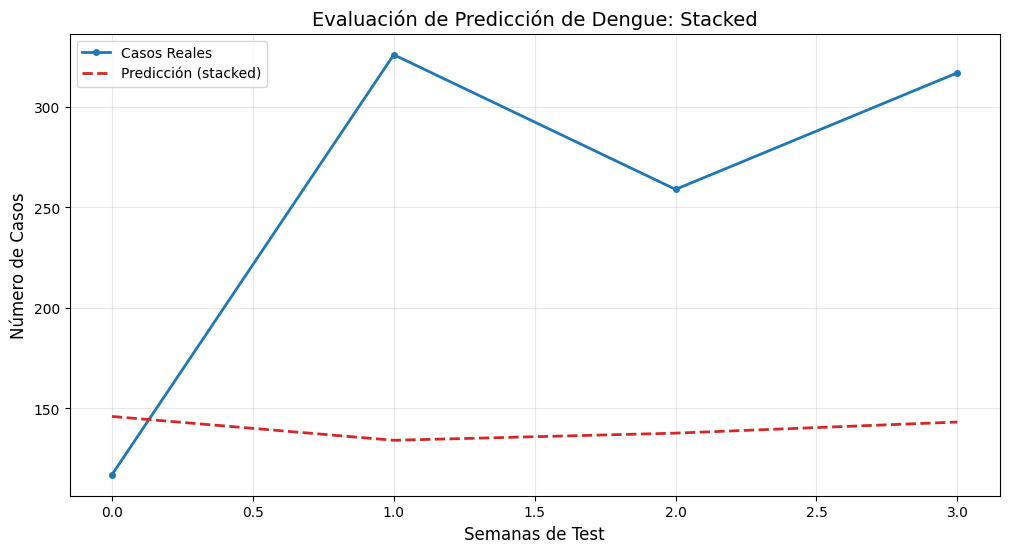


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1368

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 99.55 casos
RMSE Real: 103.19
MAPE Real: 44.95%


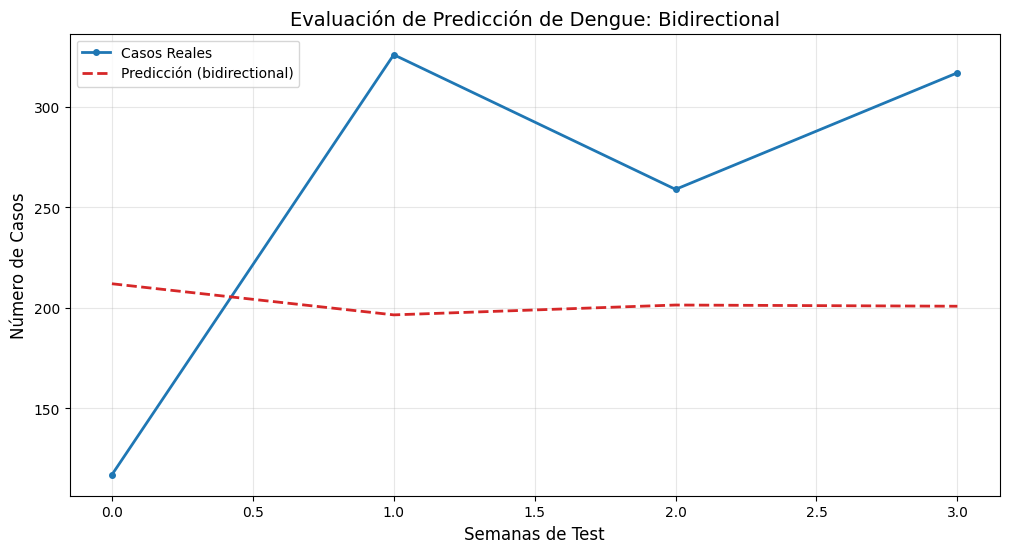


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.2305

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 132.77 casos
RMSE Real: 151.23
MAPE Real: 46.02%


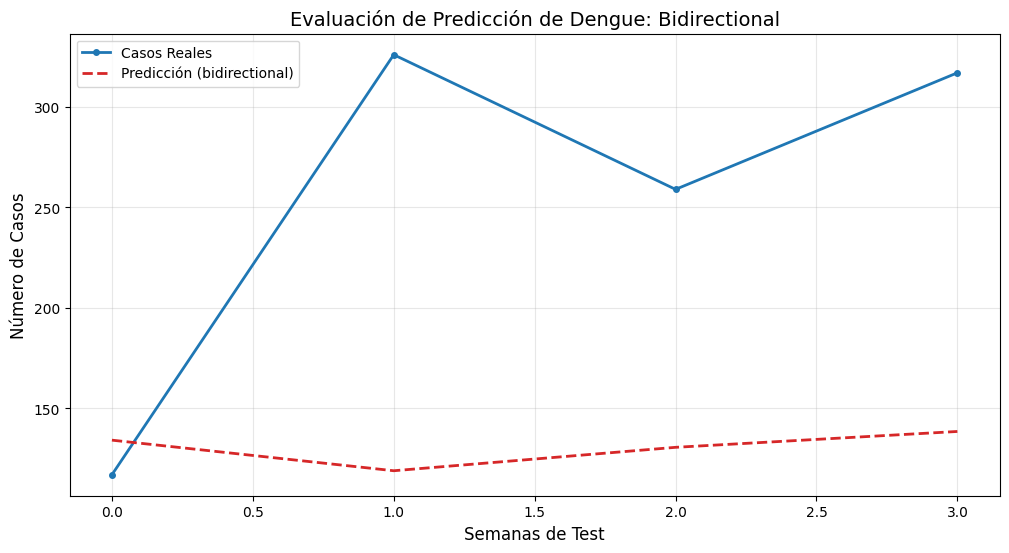

In [66]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()




# Camaguey


In [42]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Camagüey'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med", 'Humedad Relat',
    'Precipitaciones_lag5', 'Precipitaciones_lag9', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag5', 'Precipitaciones_lag9'],
      dtype='object')
(433, 8, 8) (4, 8, 8)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.1636

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 237.72 casos
RMSE Real: 247.40
MAPE Real: 37.16%


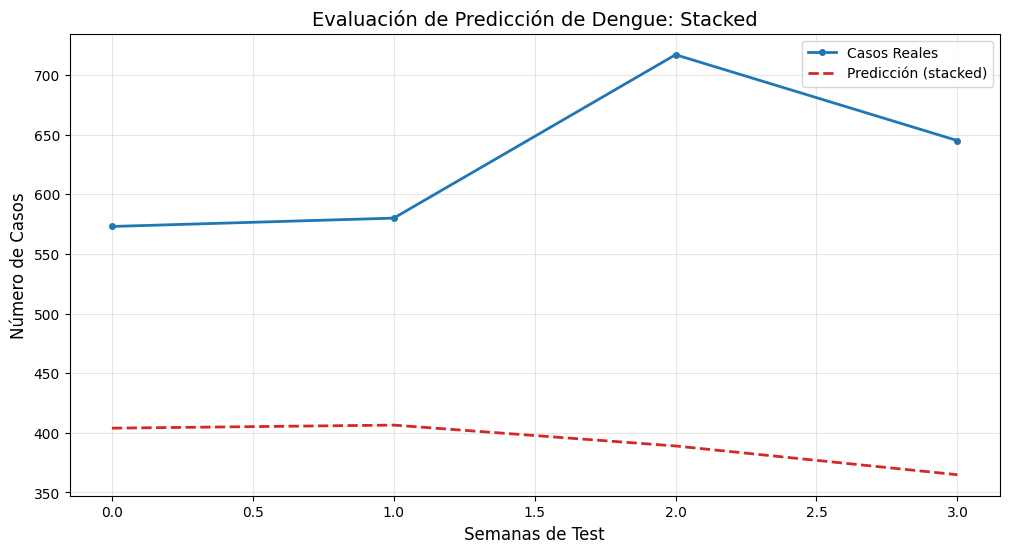


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1288

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 194.93 casos
RMSE Real: 206.93
MAPE Real: 30.28%


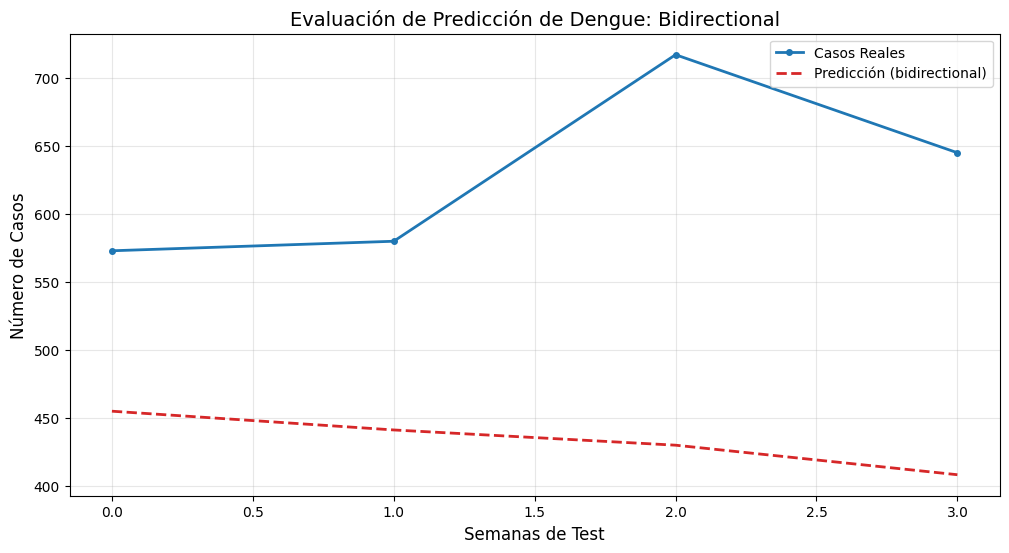


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.2113

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 296.46 casos
RMSE Real: 308.94
MAPE Real: 46.35%


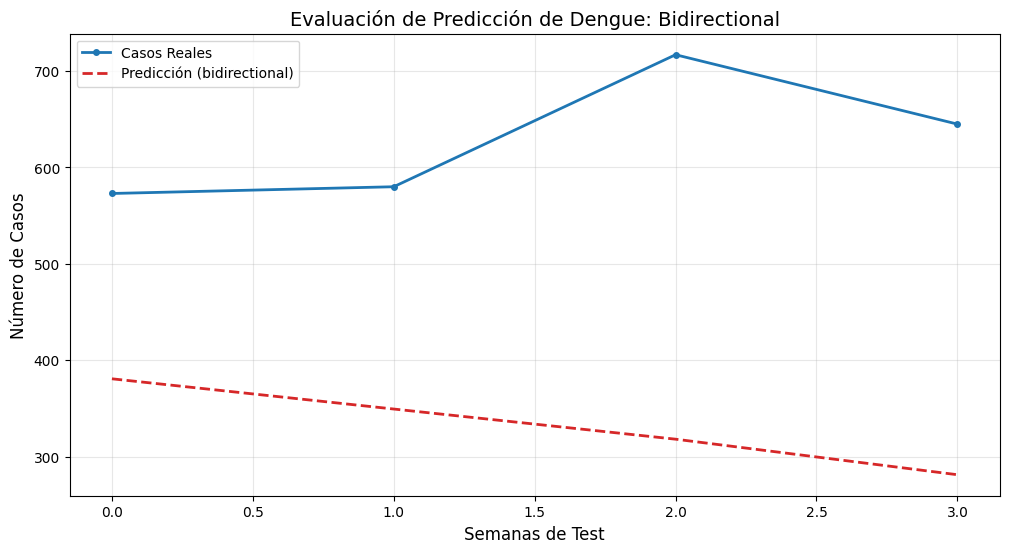

In [43]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Las Tunas

In [46]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Las_Tunas'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med",'Precipitaciones_lag10', 'Humedad Relat',
     'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag10'],
      dtype='object')
(433, 8, 7) (4, 8, 7)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.0378

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 49.50 casos
RMSE Real: 51.99
MAPE Real: 26.26%


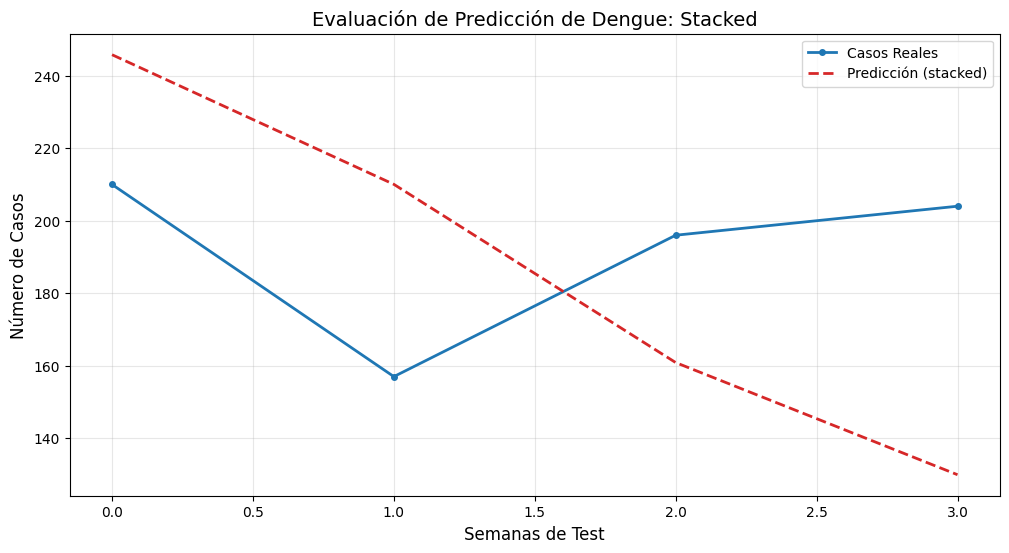


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.0422

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 48.44 casos
RMSE Real: 54.74
MAPE Real: 25.89%


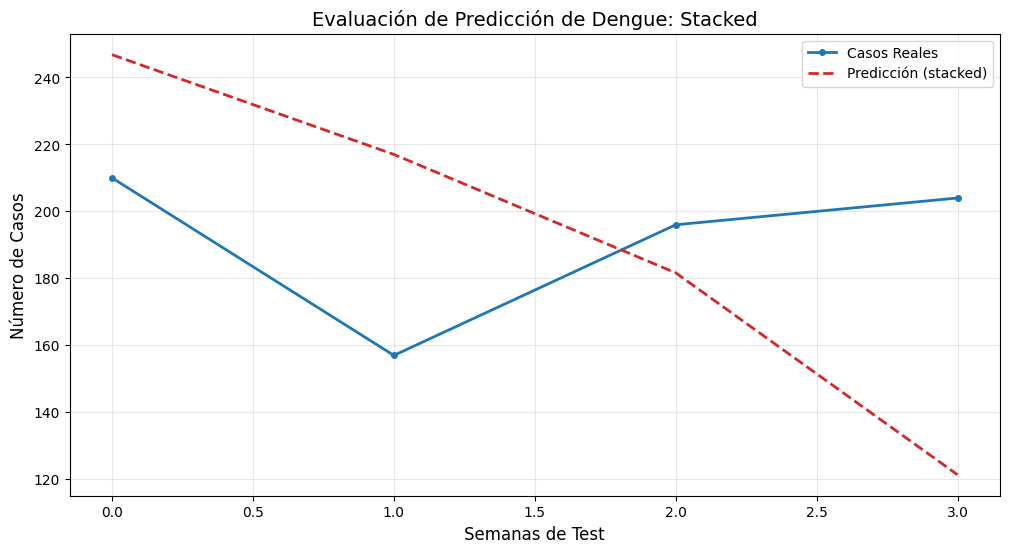


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.0350

🏆 Mejor Modelo Detectado: ATTENTION
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 44.68 casos
RMSE Real: 49.43
MAPE Real: 23.75%


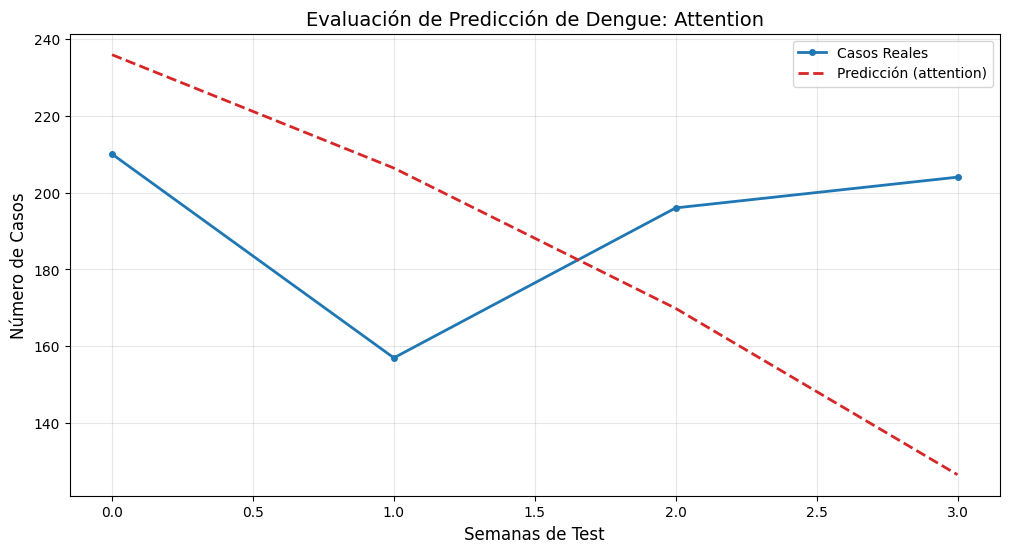

In [47]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Granma

In [63]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Granma'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue', 'Temp_Med','Hum_Rel', 'Precip', 'Mes',"Semana Estadística"
]
data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')
(440, 8, 6) (4, 8, 6)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.0602

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 19.88 casos
RMSE Real: 22.51
MAPE Real: 22.35%


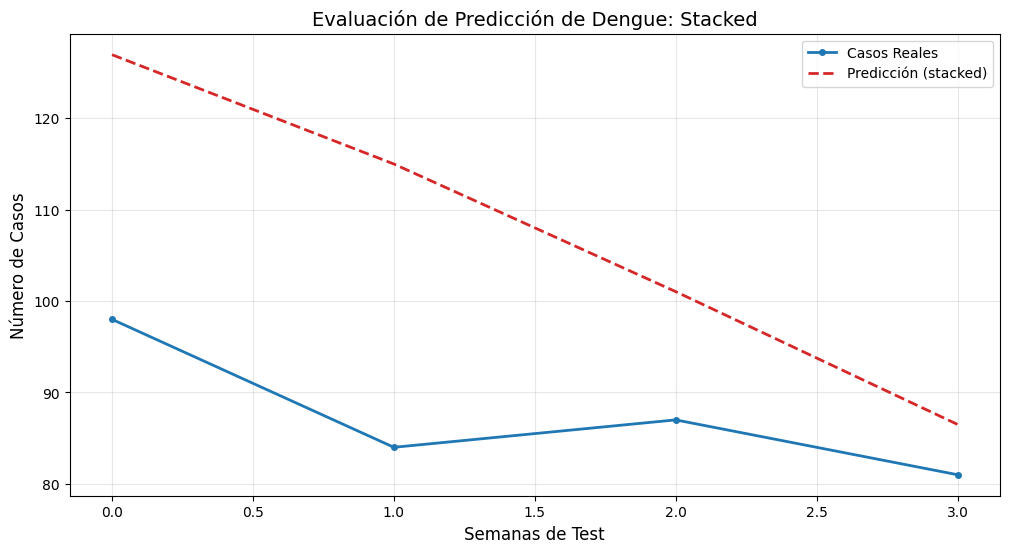


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.0507

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 21.94 casos
RMSE Real: 22.14
MAPE Real: 25.20%


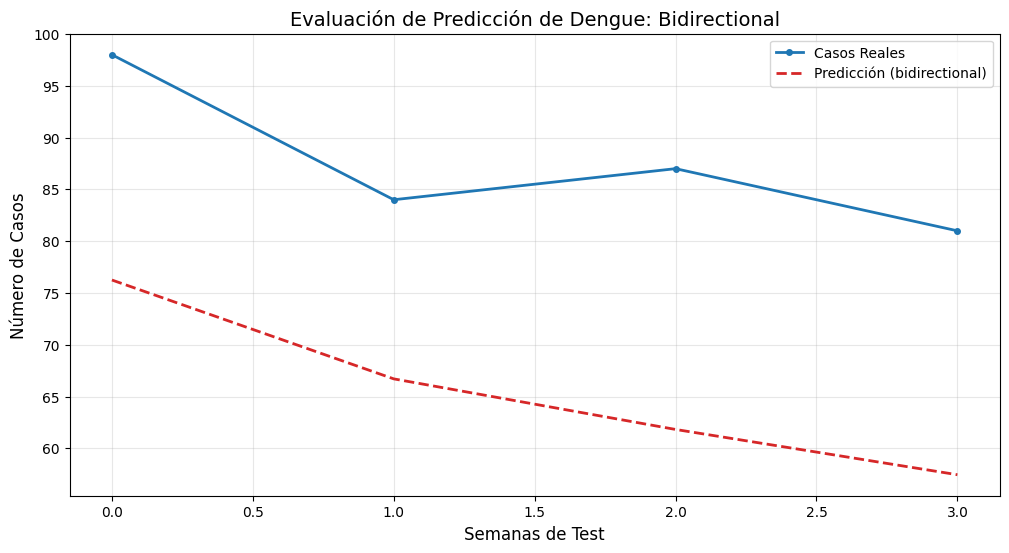


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.0392

🏆 Mejor Modelo Detectado: ATTENTION
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 17.27 casos
RMSE Real: 17.65
MAPE Real: 19.91%


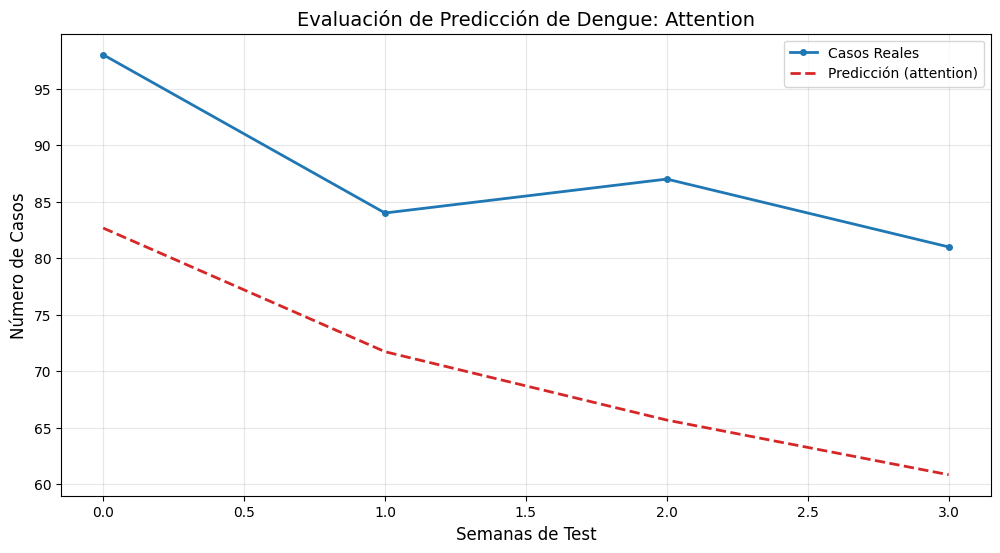

In [64]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Holguin

In [54]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Holguín'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med",'Precipitaciones_lag13', 'Humedad Relat',
    'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag13'],
      dtype='object')
(430, 8, 7) (4, 8, 7)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.1130

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 117.44 casos
RMSE Real: 119.88
MAPE Real: 91.81%


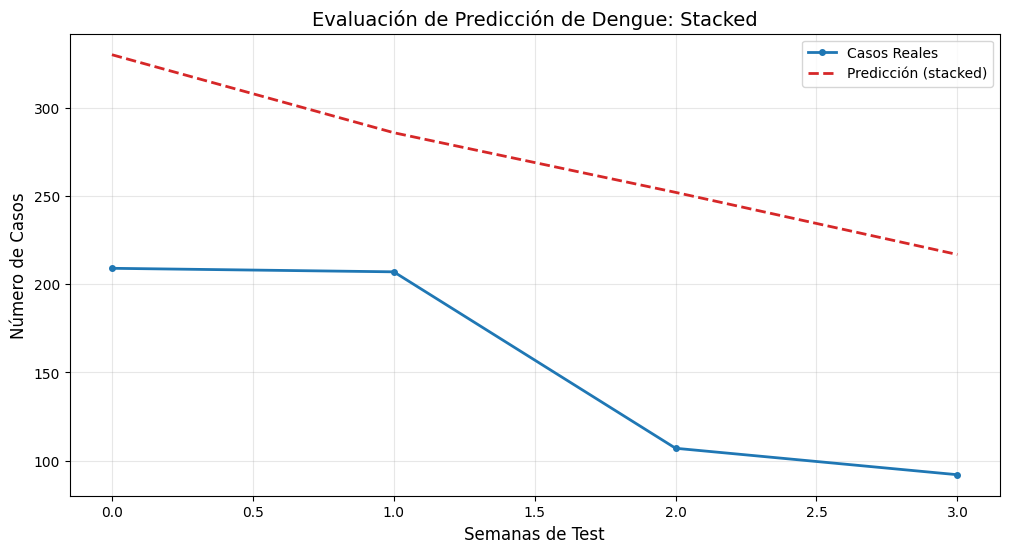


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1031

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 103.78 casos
RMSE Real: 107.32
MAPE Real: 83.13%


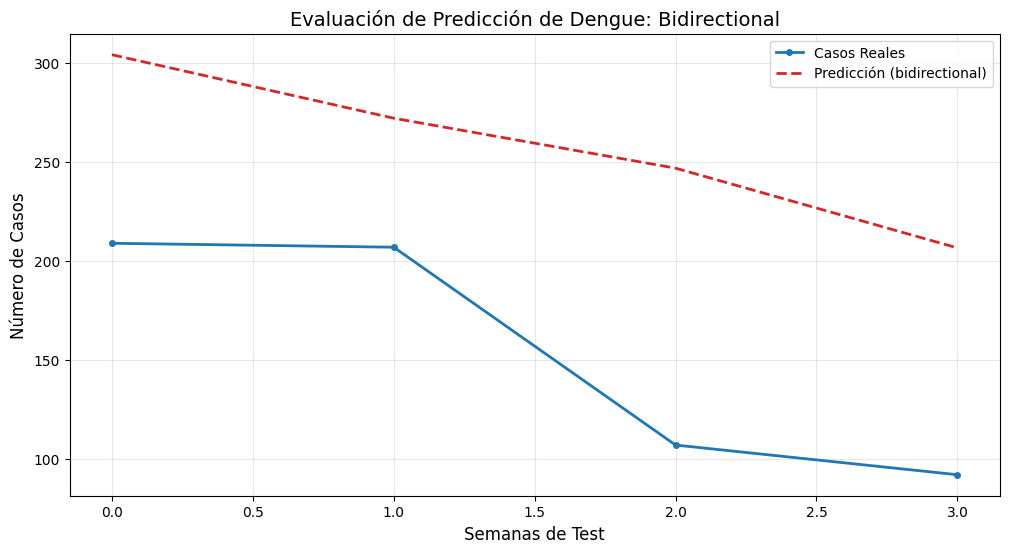


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.1633

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 187.39 casos
RMSE Real: 189.13
MAPE Real: 144.20%


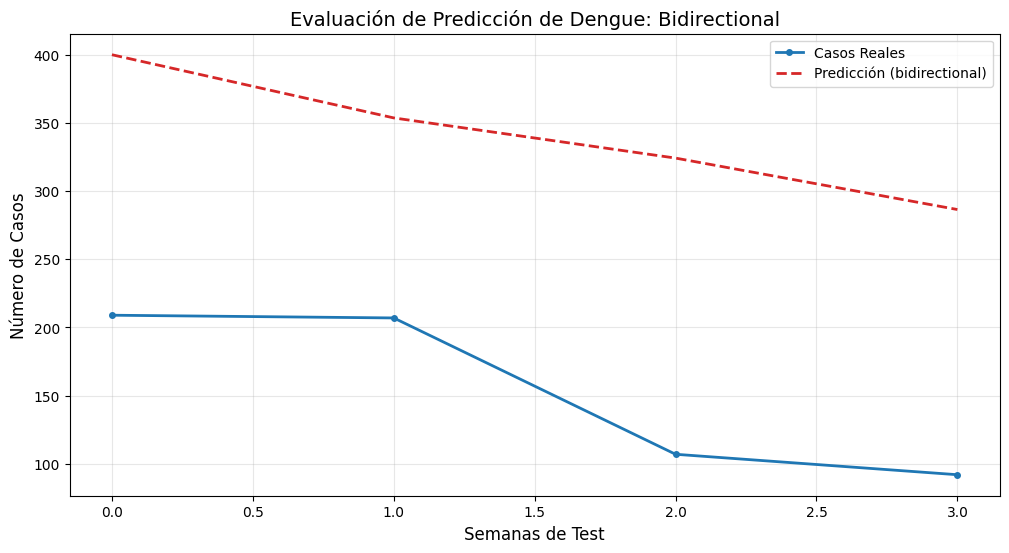

In [55]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Santiago de Cuba

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Santiago_de_Cuba'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue',"Precipitaciones","Temperatura med",'Precipitaciones_lag4', 'Humedad Relat',
    'Temperatura med_lag13', 'Temperatura med_lag15', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue',
       'Temperatura med', 'Humedad Relat', 'Precipitaciones', 'Año_y', 'Mes',
       'Precipitaciones_lag0', 'Precipitaciones_lag1', 'Precipitaciones_lag4',
       'Temperatura med_lag6', 'Temperatura med_lag12',
       'Temperatura med_lag13', 'Temperatura med_lag14',
       'Temperatura med_lag15'],
      dtype='object')



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.1649

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 83.71 casos
RMSE Real: 97.57
MAPE Real: 6.29%


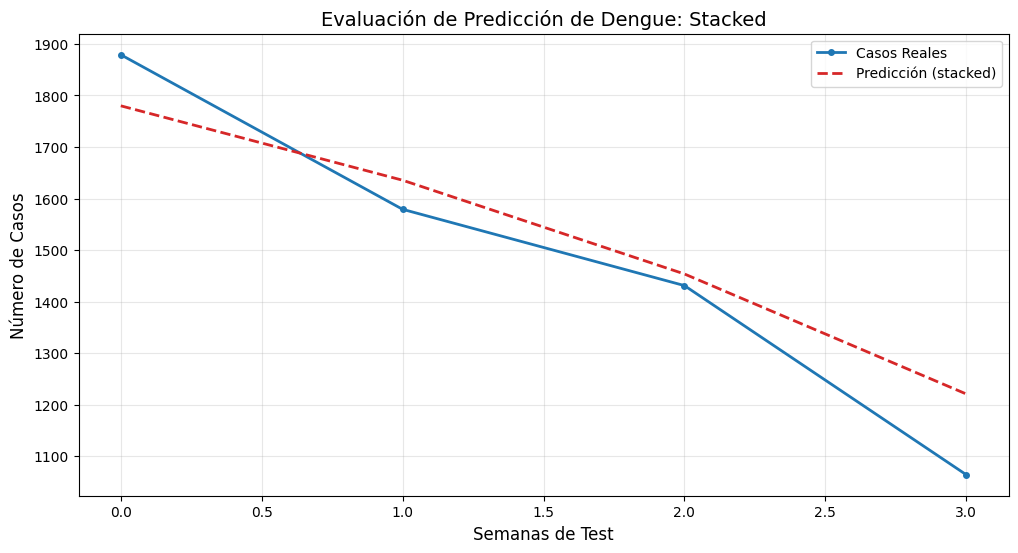


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.1765

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 148.44 casos
RMSE Real: 171.41
MAPE Real: 11.11%


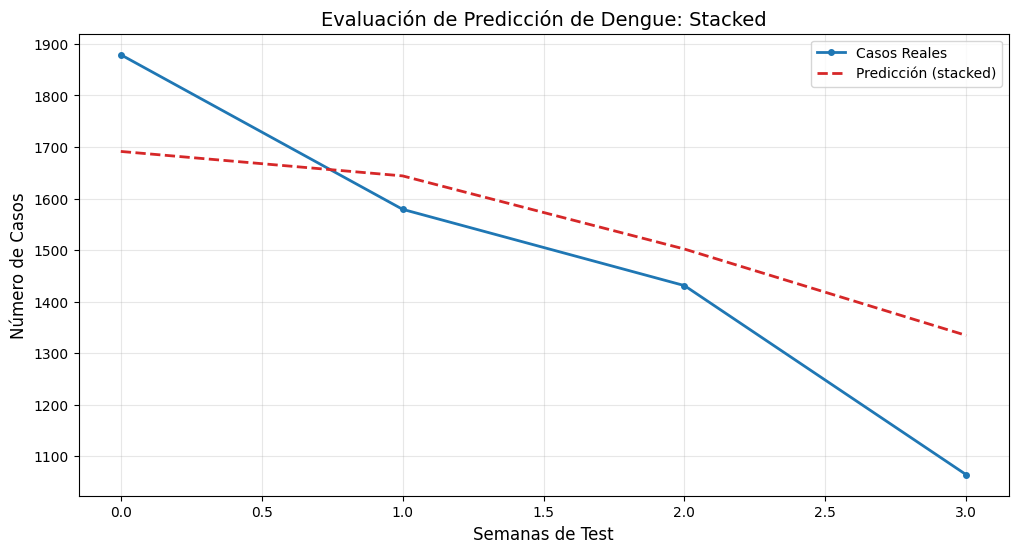


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.1801

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 287.82 casos
RMSE Real: 341.50
MAPE Real: 21.23%


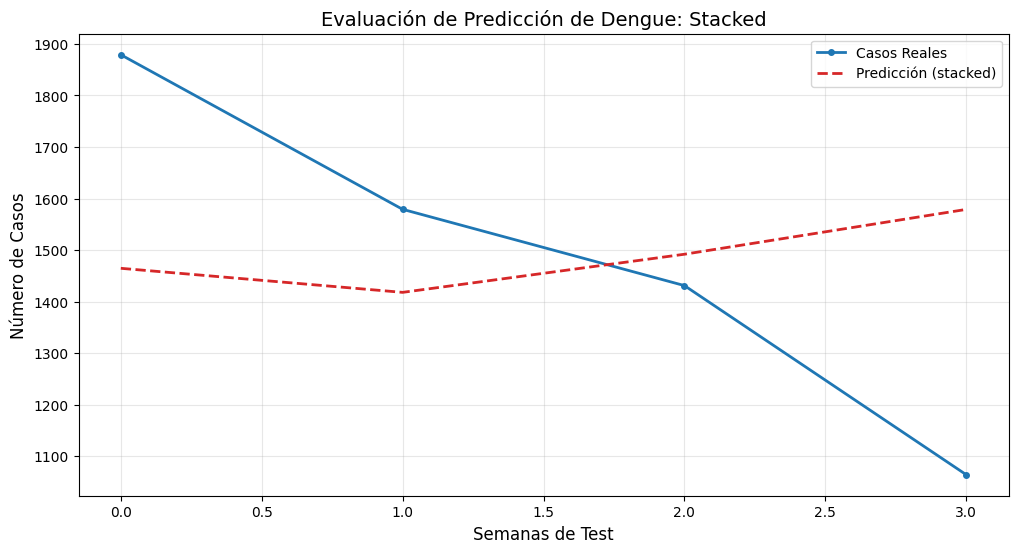

In [8]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Guantanamo

In [61]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Guantánamo'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue', 'Temp_Med','Hum_Rel', 'Precip', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')
(428, 8, 6) (4, 8, 6)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.3381

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 309.33 casos
RMSE Real: 312.09
MAPE Real: 111.26%


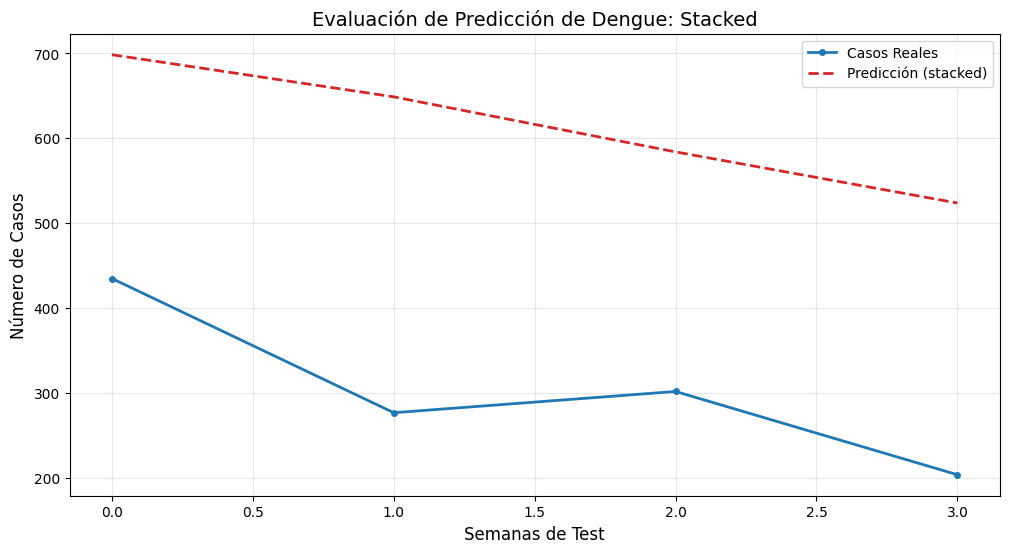


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.3268

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 296.42 casos
RMSE Real: 299.28
MAPE Real: 105.75%


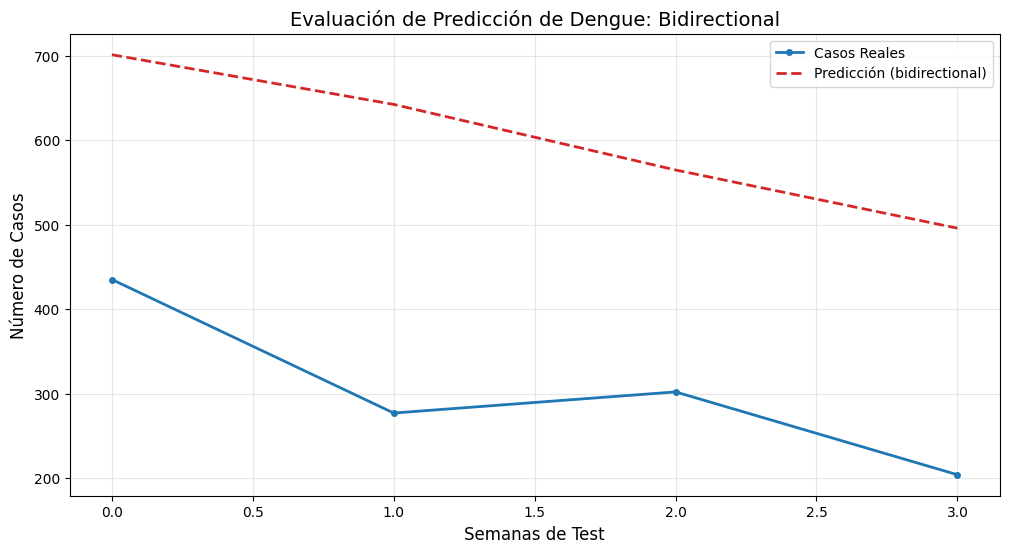


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.3117

🏆 Mejor Modelo Detectado: ATTENTION
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 279.10 casos
RMSE Real: 283.15
MAPE Real: 97.87%


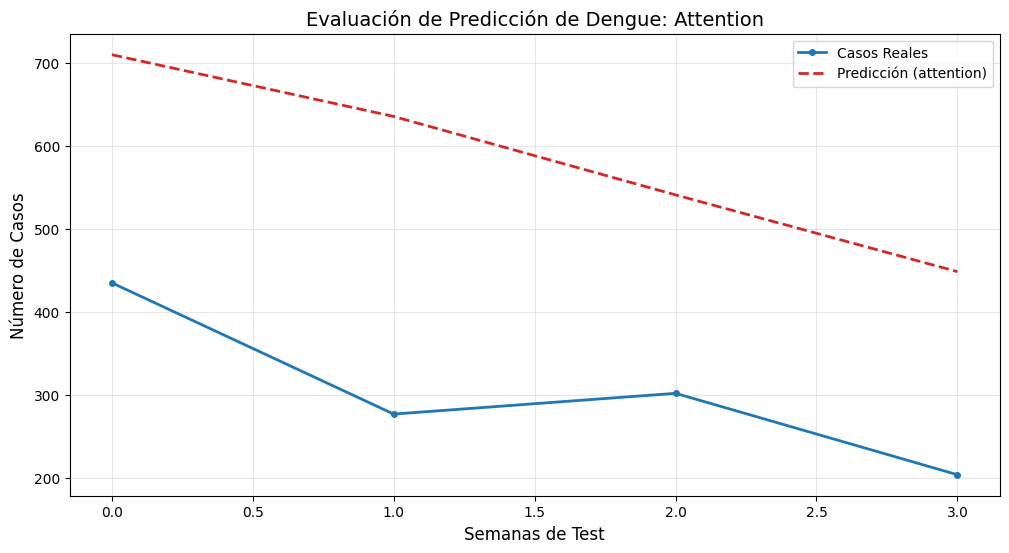

In [62]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Isla de la Juventud

In [59]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler

nombre_provincia = 'Isla_de_la_Juventud'

carpeta_salida = '/content'
nombre_archivo = f'{nombre_provincia.replace(" ", "_")}.csv'
ruta_completa = os.path.join(carpeta_salida, nombre_archivo)

df= pd.read_csv(ruta_completa)

df= df.drop(['Unnamed: 0', "Provincias"], axis=1)
print(df.columns)


features = [
    'Casos_Dengue', 'Temp_Med', 'Hum_Rel', 'Precip', 'Mes',"Semana Estadística"
]

data_selected = df[features].values

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data_selected)

def create_sequences_multi(data, n_past, n_future):
    X, y = [], []
    for i in range(n_past, len(data) - n_future + 1):
        X.append(data[i - n_past:i, :])
        # Aquí guardamos un vector de 4 valores (semanas 1 a 4)
        y.append(data[i : i + n_future, 0])
    return np.array(X), np.array(y)

# y.shape  (muestras, 4)
X, y = create_sequences_multi(data_scaled, n_past=8, n_future=4)
n_forecast = 4

y_train = y[:-n_forecast]
X_train= X[:-n_forecast]
y_test = y[-n_forecast:]
X_test = X[-n_forecast:]
print(X_train.shape,X_test.shape)

Index(['Año_x', 'Semana Estadística', 'Fecha', 'Casos_Dengue', 'Temp_Med',
       'Hum_Rel', 'Precip', 'Año_y', 'Mes'],
      dtype='object')
(440, 8, 6) (4, 8, 6)



--- Entrenando Modelo: STACKED ---
Resultado stacked: MAE = 0.0189

🏆 Mejor Modelo Detectado: STACKED
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 10.13 casos
RMSE Real: 11.70
MAPE Real: 74.31%


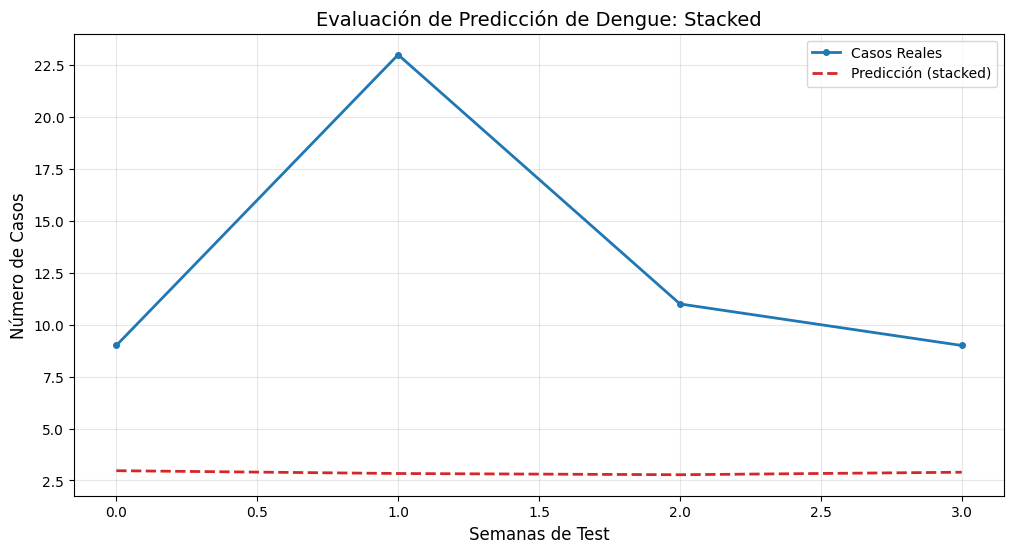


--- Entrenando Modelo: BIDIRECTIONAL ---
Resultado bidirectional: MAE = 0.0157

🏆 Mejor Modelo Detectado: BIDIRECTIONAL
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 7.41 casos
RMSE Real: 9.50
MAPE Real: 50.02%


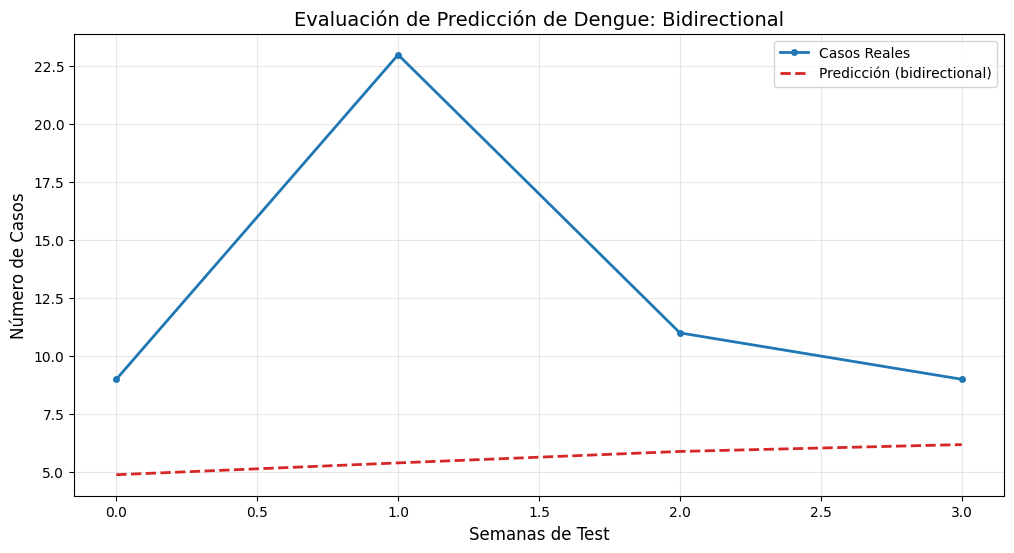


--- Entrenando Modelo: ATTENTION ---
Resultado attention: MAE = 0.0127

🏆 Mejor Modelo Detectado: ATTENTION
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
--- Métricas en Unidades Reales (Casos) ---
MAE Real: 5.88 casos
RMSE Real: 8.17
MAPE Real: 36.99%


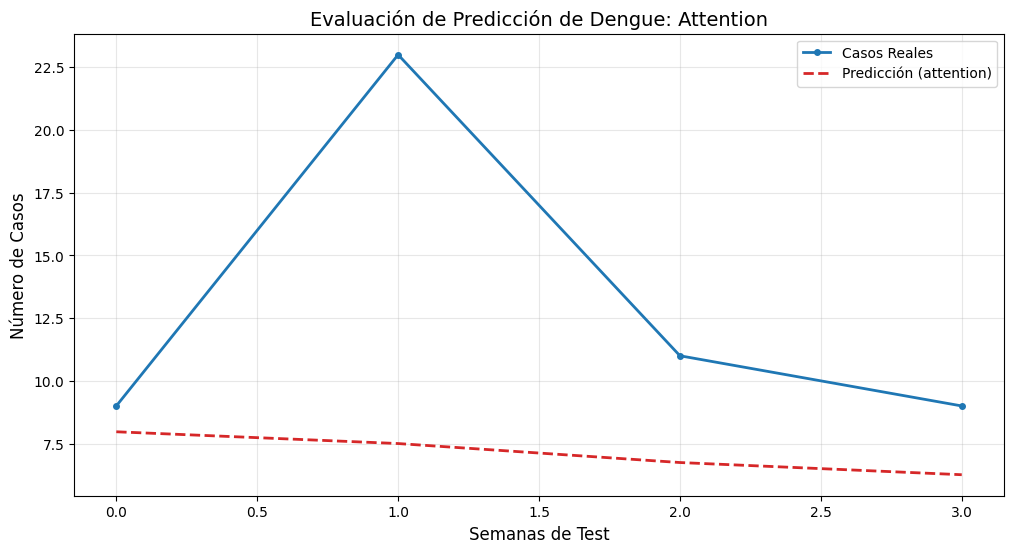

In [60]:

architectures = ['stacked', 'bidirectional', 'attention']
results = {}

for arch in architectures:
    print(f"\n--- Entrenando Modelo: {arch.upper()} ---")

    # Construir
    model = build_lstm_model(arch, (X_train.shape[1], X_train.shape[2]))

    # Entrenar con Early Stopping para evitar Overfitting
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0 # Para no llenar la consola
    )

    # Evaluar
    loss, mae = model.evaluate(X_test, y_test, verbose=0)
    results[arch] = {'MAE': mae, 'History': history}
    print(f"Resultado {arch}: MAE = {mae:.4f}")

# 1. Identificar el mejor modelo basado en el MAE guardado en tu diccionario 'results'
    mejor_tipo = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n🏆 Mejor Modelo Detectado: {mejor_tipo.upper()}")

    # 2. Obtener las predicciones del mejor modelo (debes haber guardado el objeto 'model' o re-entrenarlo)
    # Asumamos que 'mejor_modelo' es el objeto del modelo ganador
    preds_escaladas = model.predict(X_test)

    # 3. DESESCALAR para volver a "Casos de Dengue"
    # Importante: El scaler espera el mismo número de columnas que al inicio (ej. 9)
    # Creamos una matriz "dummy" para poder usar inverse_transform
    dummy_preds = np.zeros((len(preds_escaladas), data_scaled.shape[1]))
    # Si predijiste 4 semanas, evaluemos la Semana 1 por ahora para el gráfico
    dummy_preds[:, 0] = preds_escaladas[:, 0]
    preds_reales = scaler.inverse_transform(dummy_preds)[:, 0]

    # Desescalar también el y_test real
    dummy_test = np.zeros((len(y_test), data_scaled.shape[1]))
    dummy_test[:, 0] = y_test[:, 0]
    y_test_original = scaler.inverse_transform(dummy_test)[:, 0]

    # 4. Imprimir Métricas Reales
    print(f"--- Métricas en Unidades Reales (Casos) ---")
    print(f"MAE Real: {mean_absolute_error(y_test_original, preds_reales):.2f} casos")
    print(f"RMSE Real: {np.sqrt(mean_squared_error(y_test_original, preds_reales)):.2f}")
    # El MAPE puede ser inestable si hay semanas con 0 casos
    print(f"MAPE Real: {mean_absolute_percentage_error(y_test_original, preds_reales)*100:.2f}%")

    # 5. Gráfico Profesional para la Tesis
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_original, label="Casos Reales", color='#1f77b4', linewidth=2, marker='o', markersize=4)
    plt.plot(preds_reales, label=f"Predicción ({mejor_tipo})", color='#d62728', linestyle='--', linewidth=2)

    plt.title(f"Evaluación de Predicción de Dengue: {mejor_tipo.capitalize()}", fontsize=14)
    plt.xlabel("Semanas de Test", fontsize=12)
    plt.ylabel("Número de Casos", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
